Reproduce plots from "Catherina (1.2): AN Open-Source Tool to generate synthetic tropical cyclone tracks and simulate annualized damages"

In [ ]:
import pyarrow.dataset as pds

# Figure 10

Figure 10: return period sampled in historical run of catherina and other cyclone generation models (??)

This figure compares the CATHERINA model with others, which means the data for other scenarios should be retrieved to plot the correct graphs. 
The following code provides a mock example.

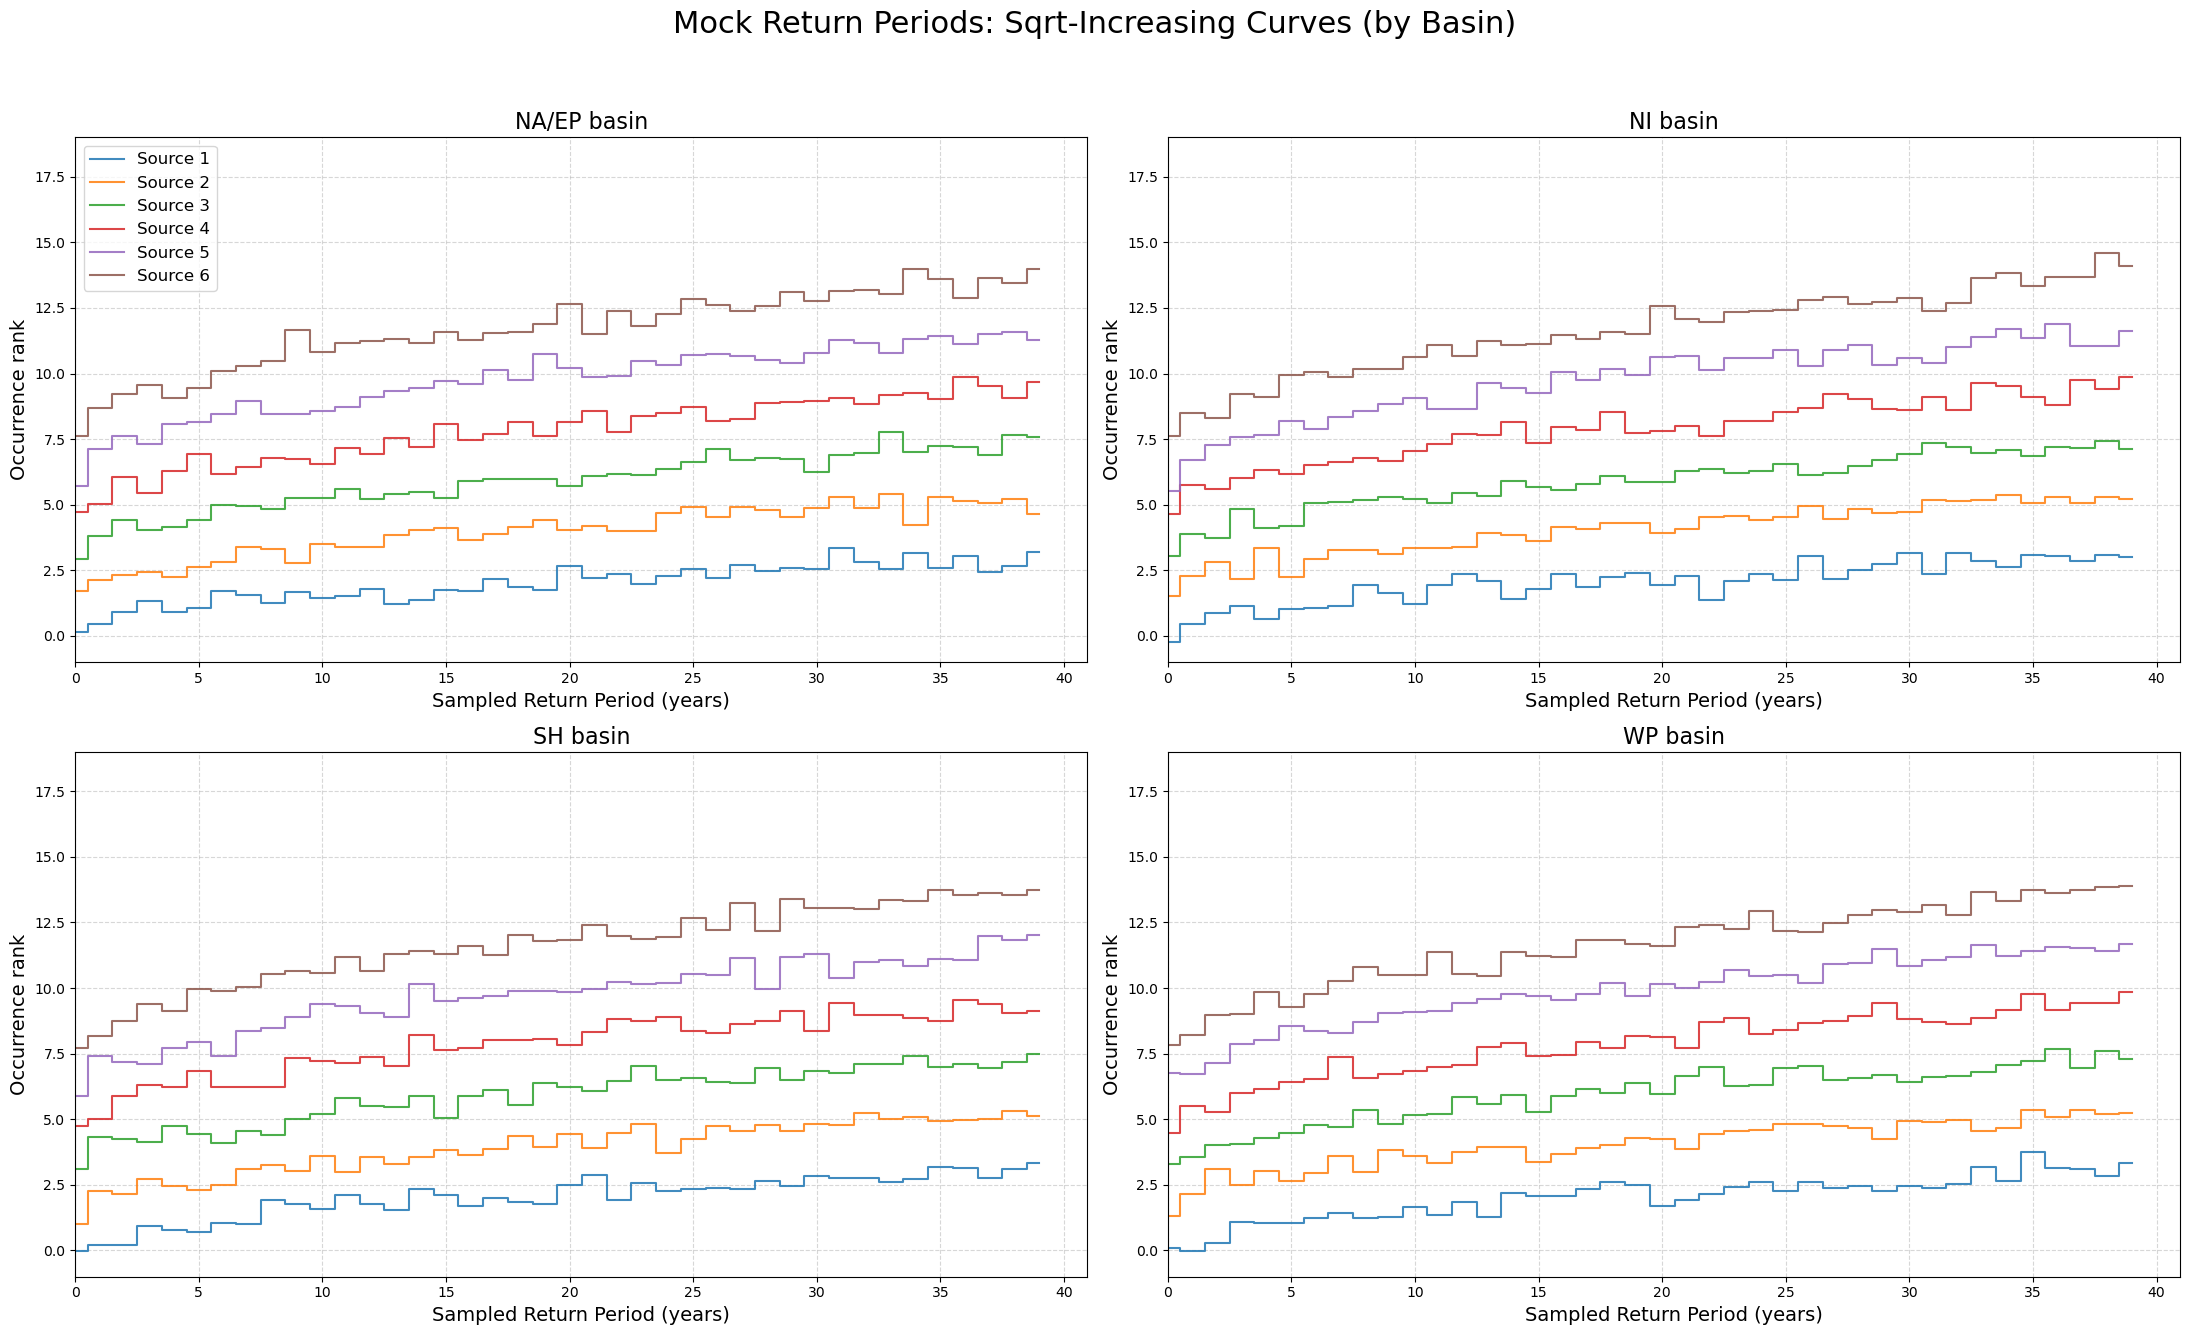

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Define basins and their order for 2x2 grid
basins = ['NA/EP', 'NI', 'SH', 'WP']
nrows, ncols = 2, 2

fig, axs = plt.subplots(nrows, ncols, figsize=(22, 14))

np.random.seed(42)
n_sources = 6
source_names = [f"Source {i+1}" for i in range(n_sources)]
# Use matplotlib.colormaps for compatibility with new matplotlib
source_colors = plt.colormaps['tab10'].colors  # tab10 is sufficient for 6

for i, basin in enumerate(basins):
    ax = axs[i // ncols, i % ncols]

    for src in range(n_sources):
        x = np.linspace(0, 39, 40)
        # Each source: show different sqrt-style increases (plus offset and noise for realism)
        scale = 0.5 + 0.5 * src / (n_sources - 1)   # Vary scale for diversity
        offset = src * 1.5                          # Different vertical offsets
        noise = np.random.normal(0, 0.3, x.shape)   # some noise per source
        y = scale * np.sqrt(x) + offset + noise

        ax.step(x, y, where="mid", color=source_colors[src],
                label=source_names[src], alpha=0.85)

    ax.set_xlabel("Sampled Return Period (years)", fontsize=14)
    ax.set_ylabel("Occurrence rank", fontsize=14)
    ax.set_title(f"{basin} basin", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xscale('linear')
    ax.set_xlim(left=0)
    # Y-limits adapted to new curves
    ax.set_ylim([-1, 7 + n_sources * 2])

    # Only put legend on first subplot to avoid clutter
    if i == 0:
        ax.legend(fontsize=12, loc='best')

fig.suptitle("Mock Return Periods: Sqrt-Increasing Curves (by Basin)", fontsize=22)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Figure 11

Figure 11: Statistics of tropical cyclone damages per year across all models
- (a) 90th and 95th percentile
- (b) mean with simulated confidence (rolling standard deviation)

Experiments
- historical 90th and 95th percentile
- SSP3-RCP70 90th and 95th percentile
- SSP4-RCP34 90th and 95th percentile
- SSP5-RCP85 90th and 95th percentile
- (SSP2 remove?)

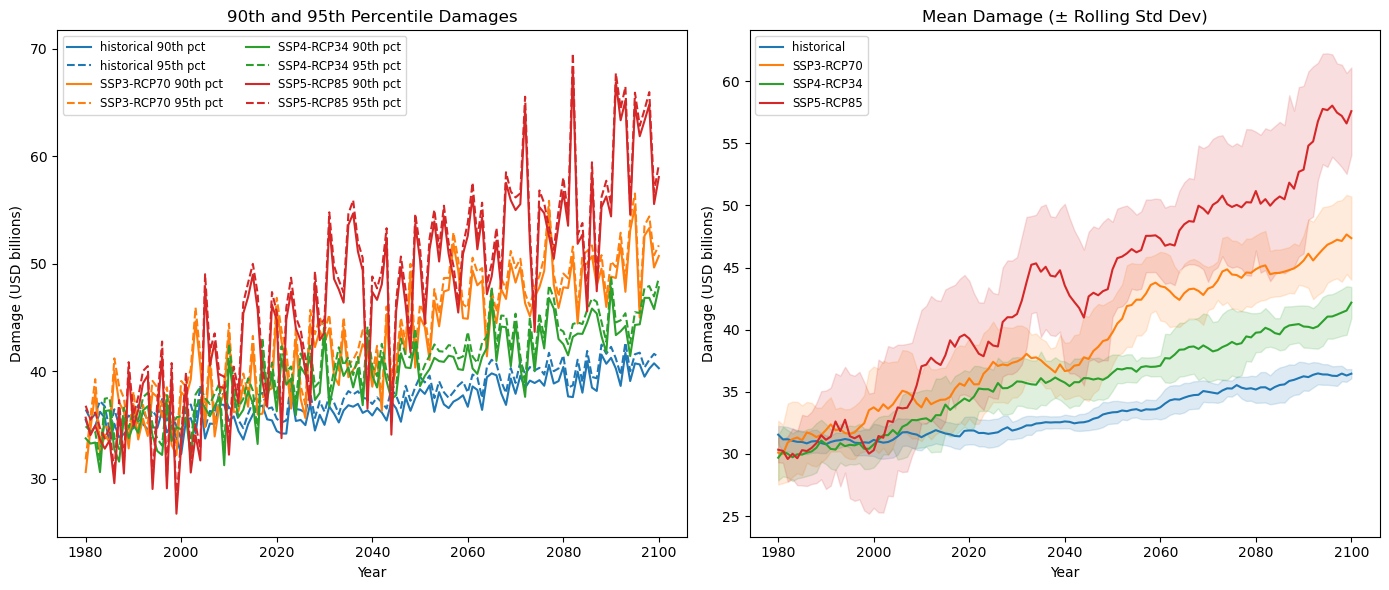

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data setup
years = np.arange(1980, 2101)
n_years = len(years)
np.random.seed(0)

scenario_labels = ["historical", "SSP3-RCP70", "SSP4-RCP34", "SSP5-RCP85"]
scenario_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

damage_lines = [
    30 + 0.05 * (years - 1980) + np.random.normal(0, 1, n_years),  # historical
    30 + 0.15 * (years - 1980) + np.random.normal(0, 3, n_years),  # SSP3-RCP70
    30 + 0.10 * (years - 1980) + np.random.normal(0, 2, n_years),  # SSP4-RCP34
    30 + 0.22 * (years - 1980) + np.random.normal(0, 5, n_years),  # SSP5-RCP85
]

# For the mock: treat each line as representing a set of annual damages for the scenario

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# --- Left: 90th/95th percentiles ---
for d, label, color in zip(damage_lines, scenario_labels, scenario_colors):
    # Simulate a distribution for each year: use normal around d with std dev (mock)
    samples = np.random.normal(loc=d, scale=3, size=(1000, n_years))
    perc90 = np.percentile(samples, 90, axis=0)
    perc95 = np.percentile(samples, 95, axis=0)
    axes[0].plot(years, perc90, color=color, linestyle="-", label=f"{label} 90th pct")
    axes[0].plot(years, perc95, color=color, linestyle="--", label=f"{label} 95th pct")

axes[0].set_title("90th and 95th Percentile Damages")
axes[0].set_ylabel("Damage (USD billions)")
axes[0].set_xlabel("Year")

# --- Right: Mean and rolling std deviation as uncertainty ---
window = 10  # rolling window in years

for d, label, color in zip(damage_lines, scenario_labels, scenario_colors):
    # Taking the mean is just d here (since d is 1 value per year)
    mean = pd.Series(d).rolling(window, center=True, min_periods=1).mean().values
    std = pd.Series(d).rolling(window, center=True, min_periods=1).std(ddof=0).values
    axes[1].plot(years, mean, color=color, label=label)
    axes[1].fill_between(years, mean-std, mean+std, color=color, alpha=0.15)

axes[1].set_title("Mean Damage (± Rolling Std Dev)")
axes[1].set_ylabel("Damage (USD billions)")
axes[1].set_xlabel("Year")

# Legends
axes[0].legend(fontsize="small", ncol=2)
axes[1].legend(fontsize="small")

plt.tight_layout()
plt.show()

# Figure 12 et 13

- Figure 12: Global damages in USD (2014) billions 2050-2075
    Models
    - mpi_esm1_2_lr
    - ukesm1_0_ll
    - miroc_es2l
    - fgoals_g3
    - ipsl_cm5a2_inca
    - access_cm2


- Figure 13: Increase of global damages simulated in Catherina with CMIP6 models over time 
    Models
    - mpi_esm1_2_lr
    - ukesm1_0_ll
    - miroc_es2l
    - fgoals_g3
    - ipsl_cm5a2_inca
    - access_cm2
    Scenarios
    - historical 90, 95
    - SSP3-RCP70 90, 95
    - SSP4-RCP34 90, 95
    - SSP5-RCP85 90, 95
    - (SSP2 remove?)

## 12 original

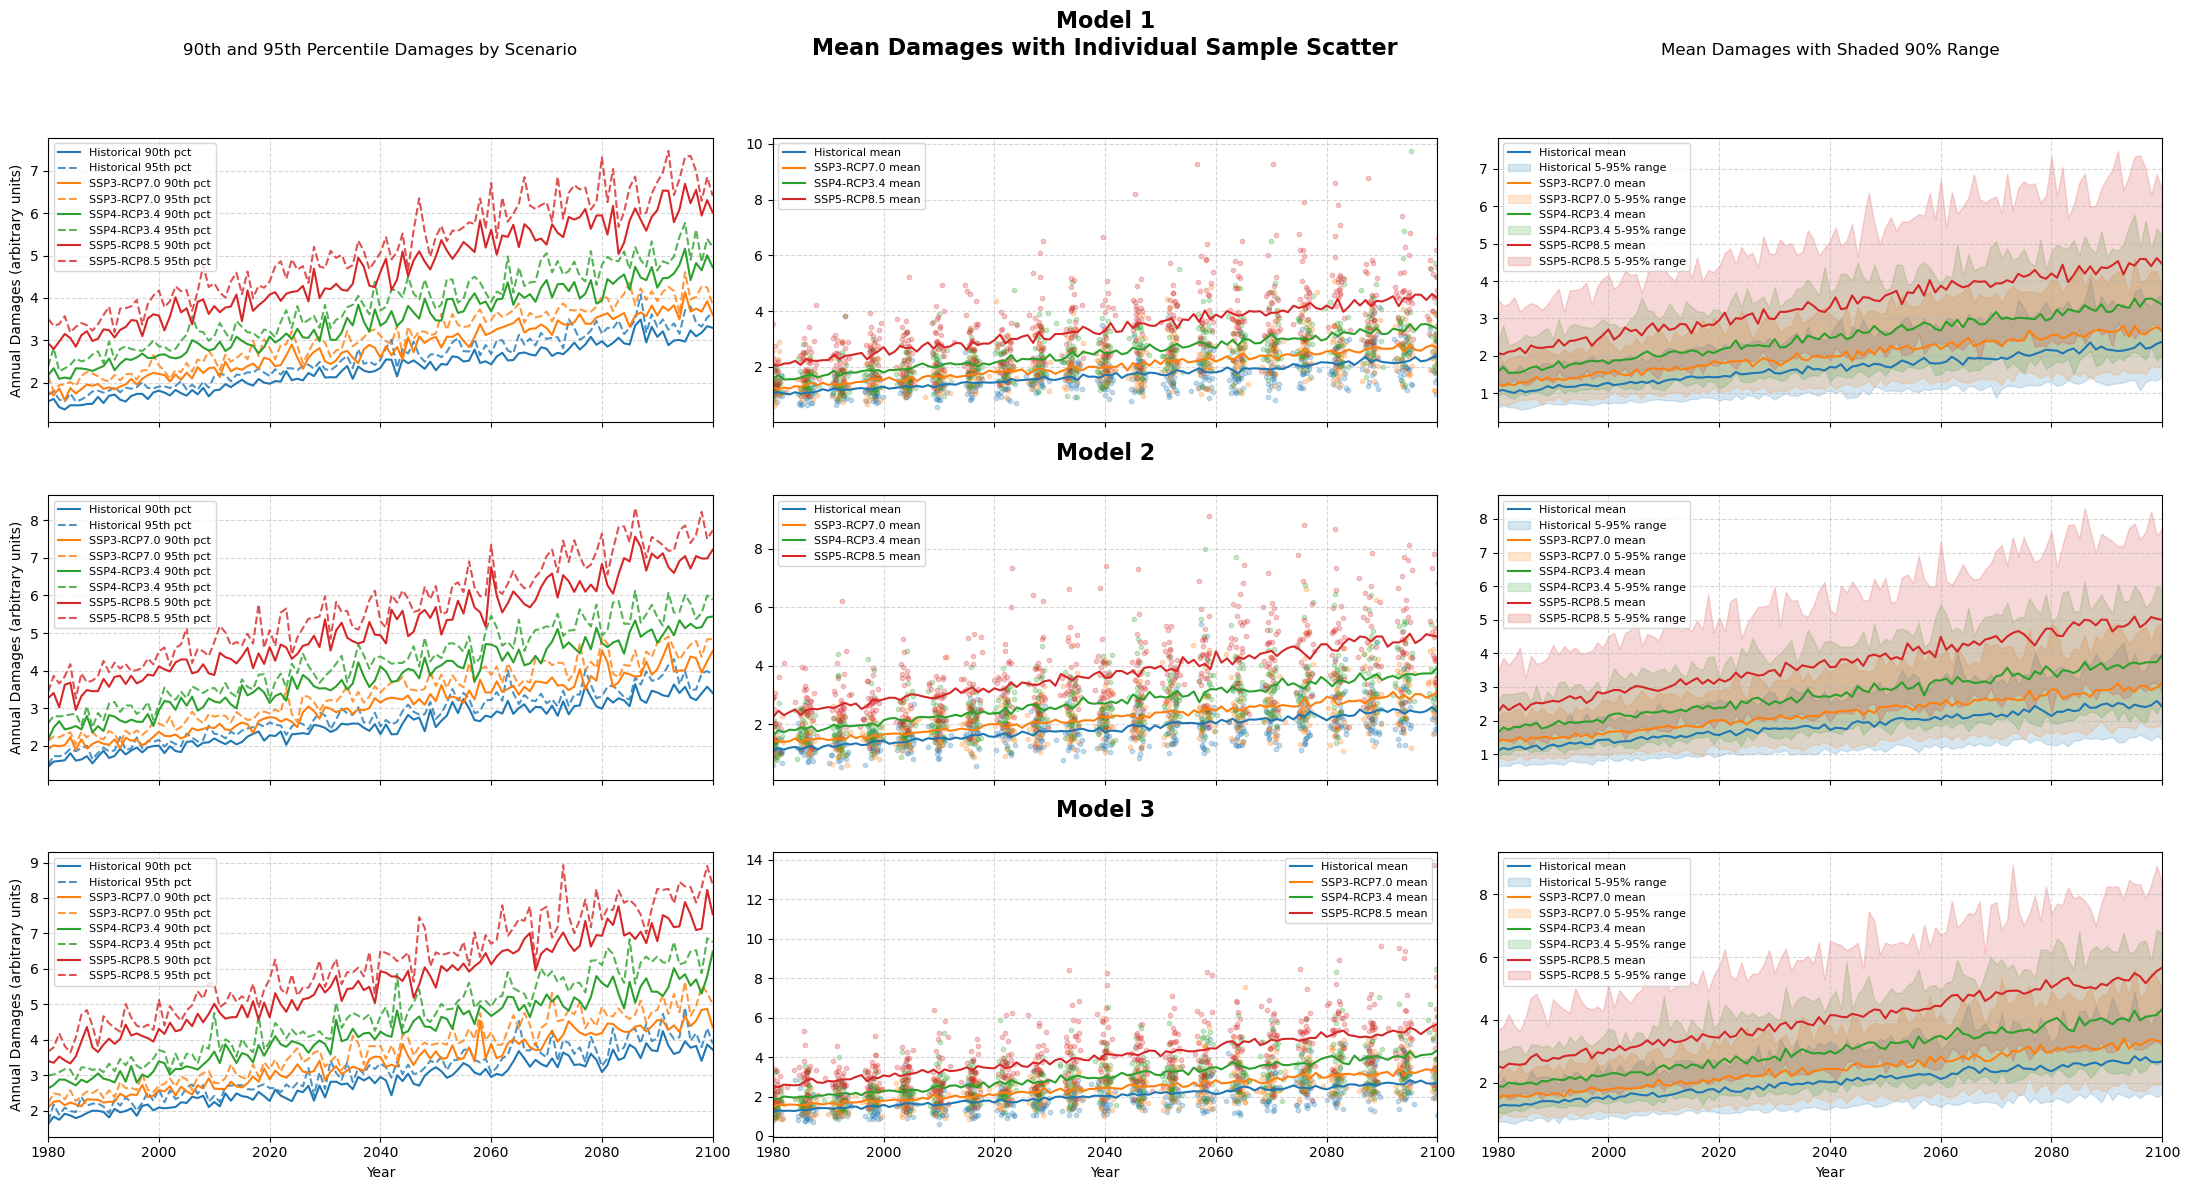

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----- CONFIG -----
np.random.seed(0)
years = np.arange(1980, 2101)  # Start at 1980, go to 2100 inclusive

# Define abstract models
model_names = ["Model 1", "Model 2", "Model 3"]
n_models = len(model_names)

# Scenarios for all models
scenarios = ["historical", "SSP3-RCP70", "SSP4-RCP34", "SSP5-RCP85"]
scenario_colors = {
    "historical": "tab:blue",
    "SSP3-RCP70": "tab:orange",
    "SSP4-RCP34": "tab:green",
    "SSP5-RCP85": "tab:red"
}
scenario_labels = {
    "historical": "Historical",
    "SSP3-RCP70": "SSP3-RCP7.0",
    "SSP4-RCP34": "SSP4-RCP3.4",
    "SSP5-RCP85": "SSP5-RCP8.5"
}
n_samples = 100

# Example: each abstract model just scales scenario_locs a bit for demonstration purposes
base_scenario_locs = {
    "historical": 1,
    "SSP3-RCP70": 1.2,
    "SSP4-RCP34": 1.5,
    "SSP5-RCP85": 2
}
model_scaling = [1.0, 1.1, 1.2]

# Damages is now: dict(model_name -> dict(scenario -> damages array))
def simulate_damages_for_models(model_names, scenarios, years, n_samples, base_scenario_locs, model_scaling):
    all_damages = {}
    for mi, model in enumerate(model_names):
        damages = {}
        scale = model_scaling[mi]
        for scen in scenarios:
            loc = base_scenario_locs[scen] * scale
            mean = np.log(loc * (1 + 0.01 * (years - years[0]))).reshape(-1,1)
            damages[scen] = np.random.lognormal(
                mean=mean,
                sigma=0.3,
                size=(len(years), n_samples)
            )
        all_damages[model] = damages
    return all_damages

def plot_percentiles(ax, years, damages, scenarios, scenario_colors, scenario_labels, percentiles=(90,95)):
    for scen in scenarios:
        vals = damages[scen]
        p_low = np.percentile(vals, percentiles[0], axis=1)
        p_high = np.percentile(vals, percentiles[1], axis=1)
        ax.plot(years, p_low, label=f"{scenario_labels[scen]} {percentiles[0]}th pct", color=scenario_colors[scen], linestyle='-')
        ax.plot(years, p_high, label=f"{scenario_labels[scen]} {percentiles[1]}th pct", color=scenario_colors[scen], linestyle='--', alpha=0.8)

def plot_mean_scatter(ax, years, damages, scenarios, scenario_colors, scenario_labels, scatter_stride=6, max_points=30):
    for scen in scenarios:
        vals = damages[scen]
        means = np.mean(vals, axis=1)
        for i in range(0, len(years), scatter_stride):
            jitter = np.random.normal(0, 0.8, size=min(vals.shape[1], max_points))
            scatter_x = np.full(jitter.shape, years[i]) + jitter
            scatter_y = vals[i, :len(jitter)]
            ax.scatter(scatter_x, scatter_y, color=scenario_colors[scen], alpha=0.25, s=10)
        ax.plot(years, means, label=f"{scenario_labels[scen]} mean", color=scenario_colors[scen])

def plot_mean_shaded(ax, years, damages, scenarios, scenario_colors, scenario_labels, p_lo=5, p_hi=95, shade_alpha=0.18):
    for scen in scenarios:
        vals = damages[scen]
        means = np.mean(vals, axis=1)
        low = np.percentile(vals, p_lo, axis=1)
        high = np.percentile(vals, p_hi, axis=1)
        ax.plot(years, means, label=f"{scenario_labels[scen]} mean", color=scenario_colors[scen])
        ax.fill_between(years, low, high, color=scenario_colors[scen], alpha=shade_alpha, label=f"{scenario_labels[scen]} {p_lo}-{p_hi}% range")

# ---- SIMULATE DATA ----
all_damages = simulate_damages_for_models(model_names, scenarios, years, n_samples, base_scenario_locs, model_scaling)

# ---- PLOTS: EACH ROW is a MODEL (abstract "Model 1", "Model 2", etc), EACH COLUMN is a plot type ----
fig, axes = plt.subplots(n_models, 3, figsize=(22, int(4*n_models)), sharex=True)

# Enforce axes shape for single-row case
if n_models == 1:
    axes = axes[np.newaxis, :]

# Add model headers atop each row of subplots
for row_idx, model in enumerate(model_names):
    # Place a row title above the middle axis of each row of subplots
    axes[row_idx, 1].set_title(model, fontsize=16, fontweight='bold', pad=25, loc='center')

for row_idx, model in enumerate(model_names):
    damages = all_damages[model]
    # PLOT 1: 90th and 95th percentile lines for all scenarios
    plot_percentiles(axes[row_idx, 0], years, damages, scenarios, scenario_colors, scenario_labels, percentiles=(90,95))
    axes[row_idx, 0].set_ylabel("Annual Damages (arbitrary units)")
    axes[row_idx, 0].legend(fontsize=8)
    # PLOT 2: Mean line and scatter for all scenarios
    plot_mean_scatter(axes[row_idx, 1], years, damages, scenarios, scenario_colors, scenario_labels, scatter_stride=6, max_points=30)
    axes[row_idx, 1].legend(fontsize=8)
    # PLOT 3: Mean and 5-95% shaded region for all scenarios
    plot_mean_shaded(axes[row_idx, 2], years, damages, scenarios, scenario_colors, scenario_labels, p_lo=5, p_hi=95, shade_alpha=0.18)
    axes[row_idx, 2].legend(fontsize=8)
    # Add grid to each subplot in the row
    for col in range(3):
        axes[row_idx, col].grid(True, linestyle='--', alpha=0.5)
    # Remove old y-axis annotation, now using title above row instead
    # axes[row_idx, 0].annotate(f"{model}", xy=(0, 0.5), xycoords='axes fraction', fontsize=14,
    #                           ha='right', va='center', rotation=90, fontweight='bold')

# Per-column (top) titles: place at top outer axes
axes[0, 0].set_title("90th and 95th Percentile Damages by Scenario", pad=60)
axes[0, 1].set_title(f"{axes[0, 1].get_title()}\nMean Damages with Individual Sample Scatter", loc='center', pad=60, fontsize=axes[0, 1].title.get_fontsize(), fontweight=axes[0, 1].title.get_fontweight())
axes[0, 2].set_title("Mean Damages with Shaded 90% Range", pad=60)

# X label and xlim for each column
for col in range(3):
    axes[-1, col].set_xlabel("Year")
    for row in range(n_models):
        axes[row, col].set_xlim(years[0], years[-1])

plt.tight_layout()
plt.show()


## 12 modifié

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----- CONFIG -----
np.random.seed(0)
years = np.arange(1980, 2101)  # Start at 1980, go to 2100 inclusive

# Define abstract models
model_names = ["ACCESS-CM2"]
n_models = len(model_names)

# Scenarios for all models
scenarios = ["historical", "SSP2-RCP45", "SSP3-RCP70", "SSP5-RCP85"]
scenario_colors = {
    "historical": "tab:green",
    "SSP2-RCP45": "tab:blue",
    "SSP3-RCP70": "tab:purple",
    "SSP5-RCP85": "tab:red"
}
scenario_labels = {
    "historical": "Historical",
    "SSP3-RCP70": "SSP3-RCP7.0",
    "SSP4-RCP34": "SSP4-RCP3.4",
    "SSP5-RCP85": "SSP5-RCP8.5"
}
n_samples = 100

###################### CHECKER CETTE PARTIE  ##############################
# Example: each abstract model just scales scenario_locs a bit for demonstration purposes
base_scenario_locs = {
    "historical": 1,
    "SSP3-RCP70": 1.2,
    "SSP4-RCP34": 1.5,
    "SSP5-RCP85": 2
}
model_scaling = [1.0, 1.1, 1.2]
#############################################################################

# Damages is now: dict(model_name -> dict(scenario -> damages array))
def simulate_damages_for_models(model_names, scenarios, years, n_samples, base_scenario_locs, model_scaling):
    all_damages = {}
    for mi, model in enumerate(model_names):
        damages = {}
        scale = model_scaling[mi]
        for scen in scenarios:
            loc = base_scenario_locs[scen] * scale
            mean = np.log(loc * (1 + 0.01 * (years - years[0]))).reshape(-1,1)
            damages[scen] = np.random.lognormal(
                mean=mean,
                sigma=0.3,
                size=(len(years), n_samples)
            )
        all_damages[model] = damages
    return all_damages

def plot_percentiles(ax, years, damages, scenarios, scenario_colors, scenario_labels, percentiles=(90,95)):
    for scen in scenarios:
        vals = damages[scen]
        p_low = np.percentile(vals, percentiles[0], axis=1)
        p_high = np.percentile(vals, percentiles[1], axis=1)
        ax.plot(years, p_low, label=f"{scenario_labels[scen]} {percentiles[0]}th pct", color=scenario_colors[scen], linestyle='-')
        ax.plot(years, p_high, label=f"{scenario_labels[scen]} {percentiles[1]}th pct", color=scenario_colors[scen], linestyle='--', alpha=0.8)

def plot_mean_scatter(ax, years, damages, scenarios, scenario_colors, scenario_labels, scatter_stride=6, max_points=30):
    for scen in scenarios:
        vals = damages[scen]
        means = np.mean(vals, axis=1)
        for i in range(0, len(years), scatter_stride):
            jitter = np.random.normal(0, 0.8, size=min(vals.shape[1], max_points))
            scatter_x = np.full(jitter.shape, years[i]) + jitter
            scatter_y = vals[i, :len(jitter)]
            ax.scatter(scatter_x, scatter_y, color=scenario_colors[scen], alpha=0.25, s=10)
        ax.plot(years, means, label=f"{scenario_labels[scen]} mean", color=scenario_colors[scen])

def plot_mean_shaded(ax, years, damages, scenarios, scenario_colors, scenario_labels, p_lo=5, p_hi=95, shade_alpha=0.18):
    for scen in scenarios:
        vals = damages[scen]
        means = np.mean(vals, axis=1)
        low = np.percentile(vals, p_lo, axis=1)
        high = np.percentile(vals, p_hi, axis=1)
        ax.plot(years, means, label=f"{scenario_labels[scen]} mean", color=scenario_colors[scen])
        ax.fill_between(years, low, high, color=scenario_colors[scen], alpha=shade_alpha, label=f"{scenario_labels[scen]} {p_lo}-{p_hi}% range")

# ---- SIMULATE DATA ----
all_damages = simulate_damages_for_models(model_names, scenarios, years, n_samples, base_scenario_locs, model_scaling)

# ---- PLOTS: EACH ROW is a MODEL (abstract "Model 1", "Model 2", etc), EACH COLUMN is a plot type ----
fig, axes = plt.subplots(n_models, 3, figsize=(22, int(4*n_models)), sharex=True)

# Enforce axes shape for single-row case
if n_models == 1:
    axes = axes[np.newaxis, :]

# Add model headers atop each row of subplots
for row_idx, model in enumerate(model_names):
    # Place a row title above the middle axis of each row of subplots
    axes[row_idx, 1].set_title(model, fontsize=16, fontweight='bold', pad=25, loc='center')

for row_idx, model in enumerate(model_names):
    damages = all_damages[model]
    # PLOT 1: 90th and 95th percentile lines for all scenarios
    plot_percentiles(axes[row_idx, 0], years, damages, scenarios, scenario_colors, scenario_labels, percentiles=(90,95))
    axes[row_idx, 0].set_ylabel("Annual Damages (arbitrary units)")
    axes[row_idx, 0].legend(fontsize=8)
    # PLOT 2: Mean line and scatter for all scenarios
    plot_mean_scatter(axes[row_idx, 1], years, damages, scenarios, scenario_colors, scenario_labels, scatter_stride=6, max_points=30)
    axes[row_idx, 1].legend(fontsize=8)
    # PLOT 3: Mean and 5-95% shaded region for all scenarios
    plot_mean_shaded(axes[row_idx, 2], years, damages, scenarios, scenario_colors, scenario_labels, p_lo=5, p_hi=95, shade_alpha=0.18)
    axes[row_idx, 2].legend(fontsize=8)
    # Add grid to each subplot in the row
    for col in range(3):
        axes[row_idx, col].grid(True, linestyle='--', alpha=0.5)
    # Remove old y-axis annotation, now using title above row instead
    # axes[row_idx, 0].annotate(f"{model}", xy=(0, 0.5), xycoords='axes fraction', fontsize=14,
    #                           ha='right', va='center', rotation=90, fontweight='bold')

# Per-column (top) titles: place at top outer axes
axes[0, 0].set_title("90th and 95th Percentile Damages by Scenario", pad=60)
axes[0, 1].set_title(f"{axes[0, 1].get_title()}\nMean Damages with Individual Sample Scatter", loc='center', pad=60, fontsize=axes[0, 1].title.get_fontsize(), fontweight=axes[0, 1].title.get_fontweight())
axes[0, 2].set_title("Mean Damages with Shaded 90% Range", pad=60)

# X label and xlim for each column
for col in range(3):
    axes[-1, col].set_xlabel("Year")
    for row in range(n_models):
        axes[row, col].set_xlim(years[0], years[-1])

plt.tight_layout()
plt.show()

KeyError: 'SSP2-RCP45'

- Figure 14: Mean and standardized error in global cyclone damages (barplots)

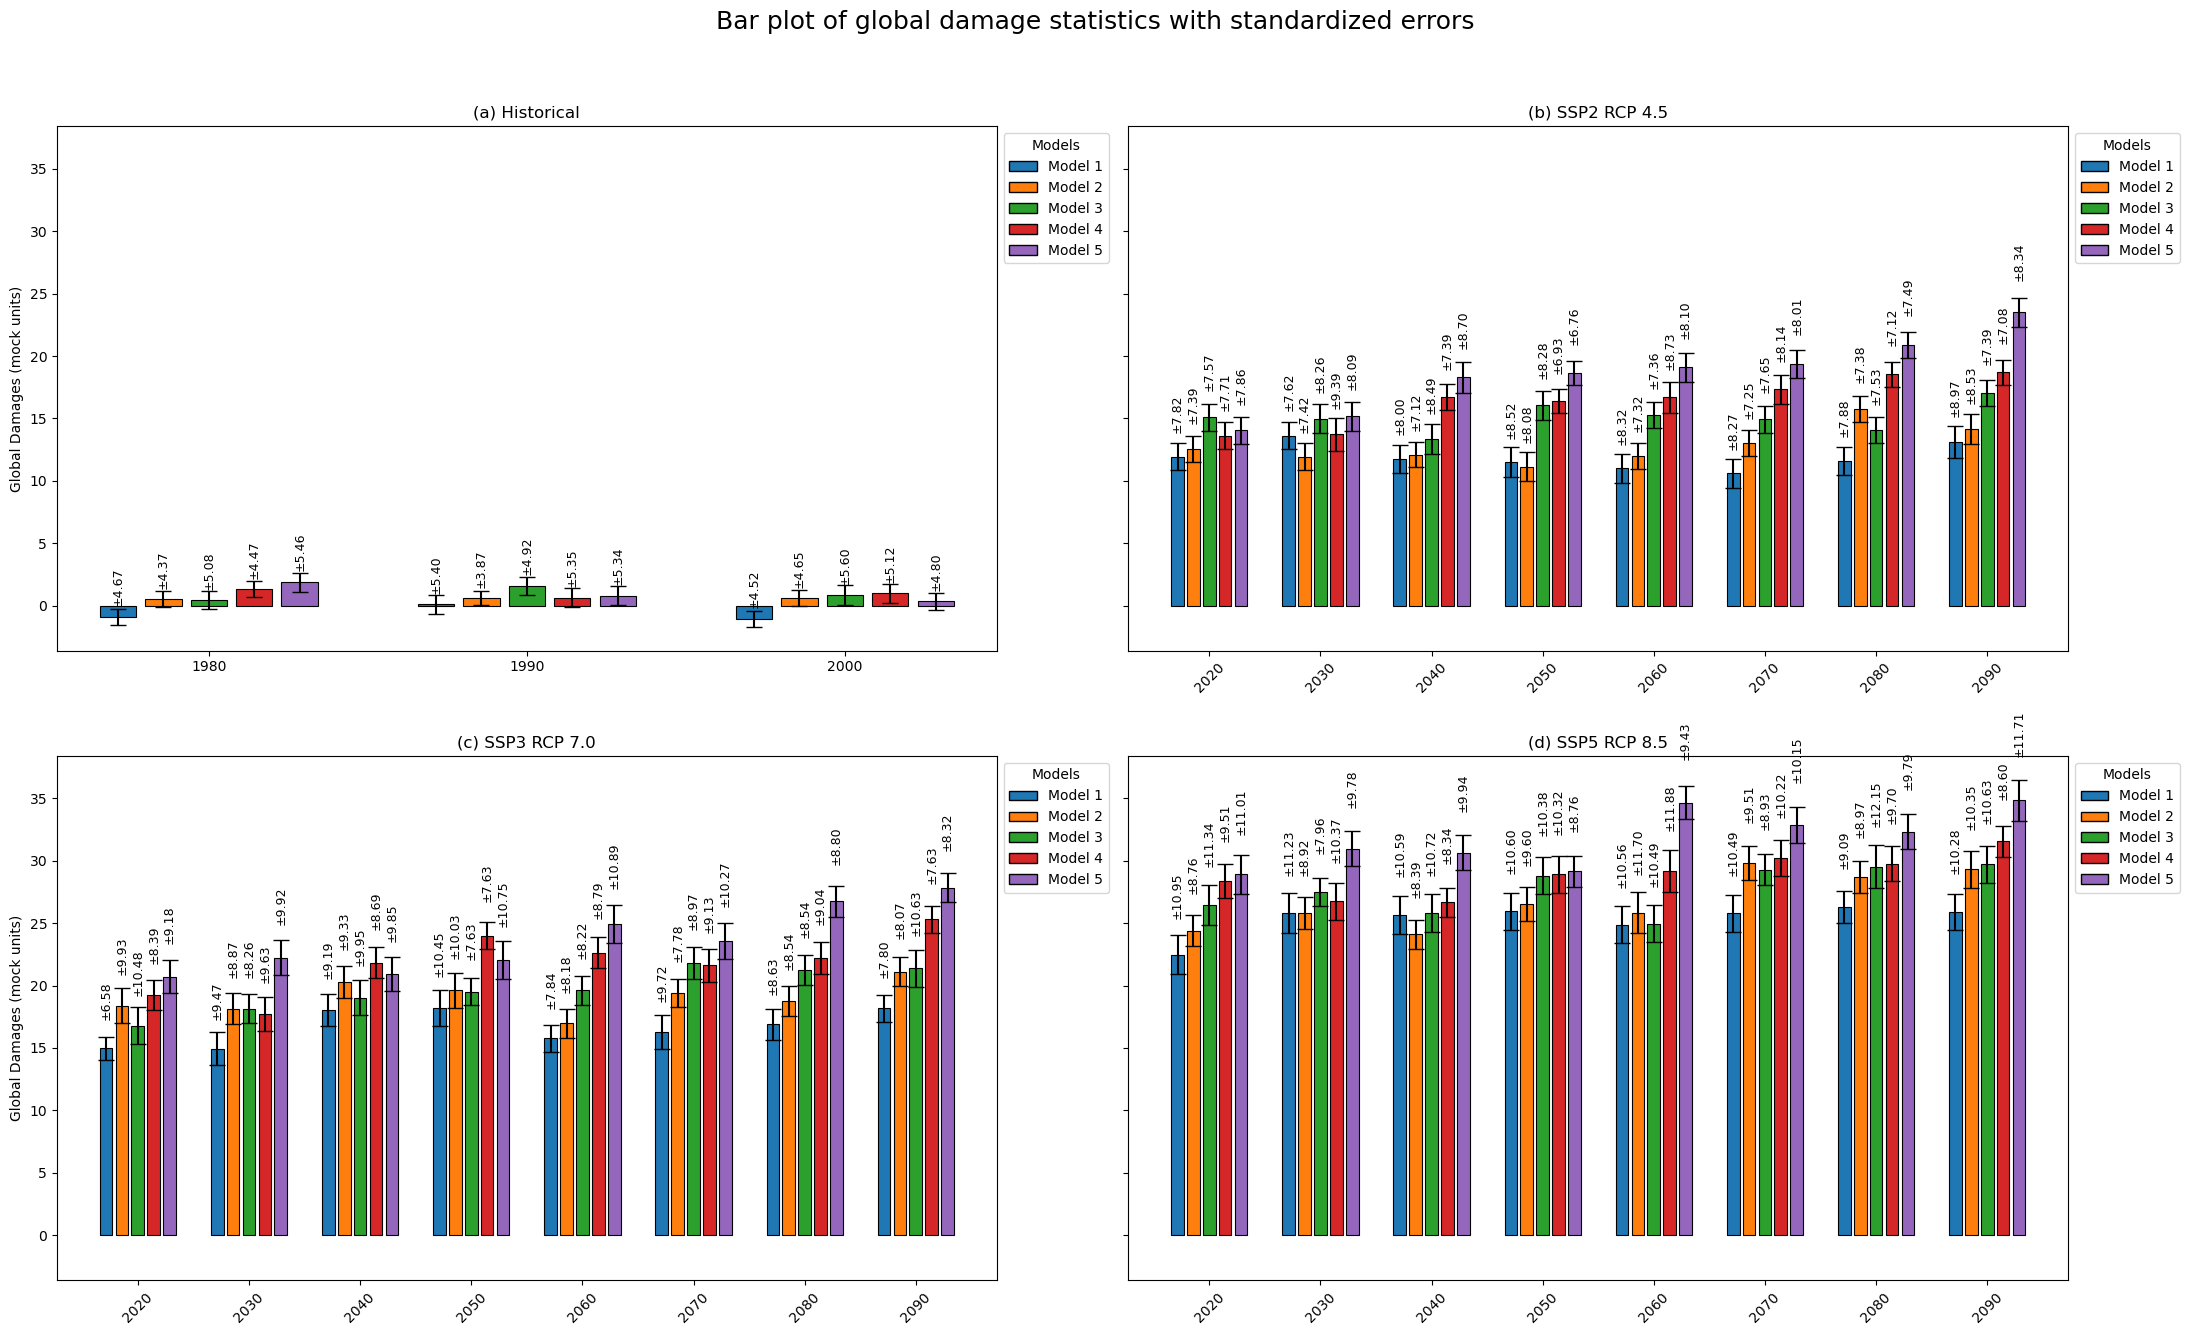

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def generate_mock_data(years, num_models=5, mean_func=None, scale=5):
    """
    Generate mock data for given years and number of models.
    mean_func: function(year, model_index) -> mean value for this model/year
    Returns: dict of years -> list of arrays (one per model)
    """
    data = {}
    for year in years:
        yearly_data = []
        for mi in range(num_models):
            mean = mean_func(year, mi) if mean_func else (mi + 1) * year / 10000
            yearly_data.append(np.random.normal(loc=mean, scale=scale, size=50))
        data[year] = yearly_data
    return data

def plot_grouped_barplots(ax, data, years, models, title, xtick_rotation=0, ylabel=None, model_colors=None):
    """
    Plot grouped barplots for multiple years, each with values per model.
    Each bar shows the mean, with standardized error on top.
    """
    if model_colors is None:
        cmap = plt.colormaps['tab10']
        model_colors = [cmap(i % 10) for i in range(len(models))]
    
    num_models = len(models)
    num_years = len(years)
    gap = 2.0  # space between year groups
    bar_width = 0.8
    step = num_models + gap
    indices = []
    means = []
    stds = []
    ses = []
    bar_colors = []
    for i, year in enumerate(years):
        for m in range(num_models):
            idx = i * step + m
            data_arr = np.asarray(data[year][m])
            mean = data_arr.mean()
            std = data_arr.std(ddof=1)
            se = std / np.sqrt(len(data_arr))
            indices.append(idx)
            means.append(mean)
            stds.append(std)
            ses.append(se)
            bar_colors.append(model_colors[m])
    
    # bar plot
    bars = ax.bar(
        indices, means, yerr=ses, color=bar_colors, width=bar_width, capsize=6, edgecolor="black", linewidth=0.8
    )
    
    # Show standardized errors as text above bar
    for idx, m, std in zip(indices, means, stds):
        # Standardized error = error / std
        ax.text(
            idx, m + 0.05*abs(m) + max(ses), 
            f"±{std:.2f}", fontsize=9, ha="center", va="bottom", rotation=90
        )
    
    # Set xticks (group midpoints)
    xtick_positions = [i*step + (num_models-1)/2 for i in range(len(years))]
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels([str(y) for y in years], rotation=xtick_rotation)
    ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    
    # Add legend for model colors
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=model_colors[i], edgecolor='black', label=models[i]) for i in range(num_models)]
    ax.legend(handles=handles, title="Models", loc="upper left", bbox_to_anchor=(1, 1))

# Settings
np.random.seed(42)
models = [f"Model {i+1}" for i in range(5)]
historical_years = [1980, 1990, 2000]
future_years = list(range(2020, 2100, 10))
num_models = 5

# Assign distinct colors for models (repeat tab10 if more than 10)
cmap = plt.colormaps['tab10']
model_colors = [cmap(i % 10) for i in range(num_models)]

# Mean functions for variety in plots
def mean_historical(year, mi):
    return (mi + 1) * year / 9000

def mean_future(year, mi):
    return (mi + 1) * (year - 1980) / 50 + 10

# Data generation
historical_data = generate_mock_data(historical_years, num_models, mean_historical, scale=5)
future_scenarios = {
    "SSP2 RCP 4.5": generate_mock_data(future_years, num_models, mean_future, scale=8),
    "SSP3 RCP 7.0": generate_mock_data(future_years, num_models, lambda y, mi: mean_future(y, mi) + 6, scale=9),
    "SSP5 RCP 8.5": generate_mock_data(future_years, num_models, lambda y, mi: mean_future(y, mi) + 14, scale=10)
}

# --- PLOTTING: Ensure all are barplots even for historical ---

fig, axes = plt.subplots(2, 2, figsize=(22, 14), sharey=True)
axes = axes.flatten()

# Fix for historical plot: clear axis before plotting (in case old boxplot remains)
for ax in axes:
    ax.clear()  # prevent any lingering old plots

plot_grouped_barplots(
    axes[0], historical_data, historical_years, models,
    title="(a) Historical", ylabel="Global Damages (mock units)", model_colors=model_colors
)
plot_grouped_barplots(
    axes[1], future_scenarios["SSP2 RCP 4.5"], future_years, models,
    title="(b) SSP2 RCP 4.5", xtick_rotation=45, model_colors=model_colors
)
plot_grouped_barplots(
    axes[2], future_scenarios["SSP3 RCP 7.0"], future_years, models,
    title="(c) SSP3 RCP 7.0", xtick_rotation=45, ylabel="Global Damages (mock units)", model_colors=model_colors
)
plot_grouped_barplots(
    axes[3], future_scenarios["SSP5 RCP 8.5"], future_years, models,
    title="(d) SSP5 RCP 8.5", xtick_rotation=45, model_colors=model_colors
)

plt.suptitle("Bar plot of global damage statistics with standardized errors", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


- Figure 15: boxplots of global damage statistics

/tmp/ipykernel_1401/2042204838.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


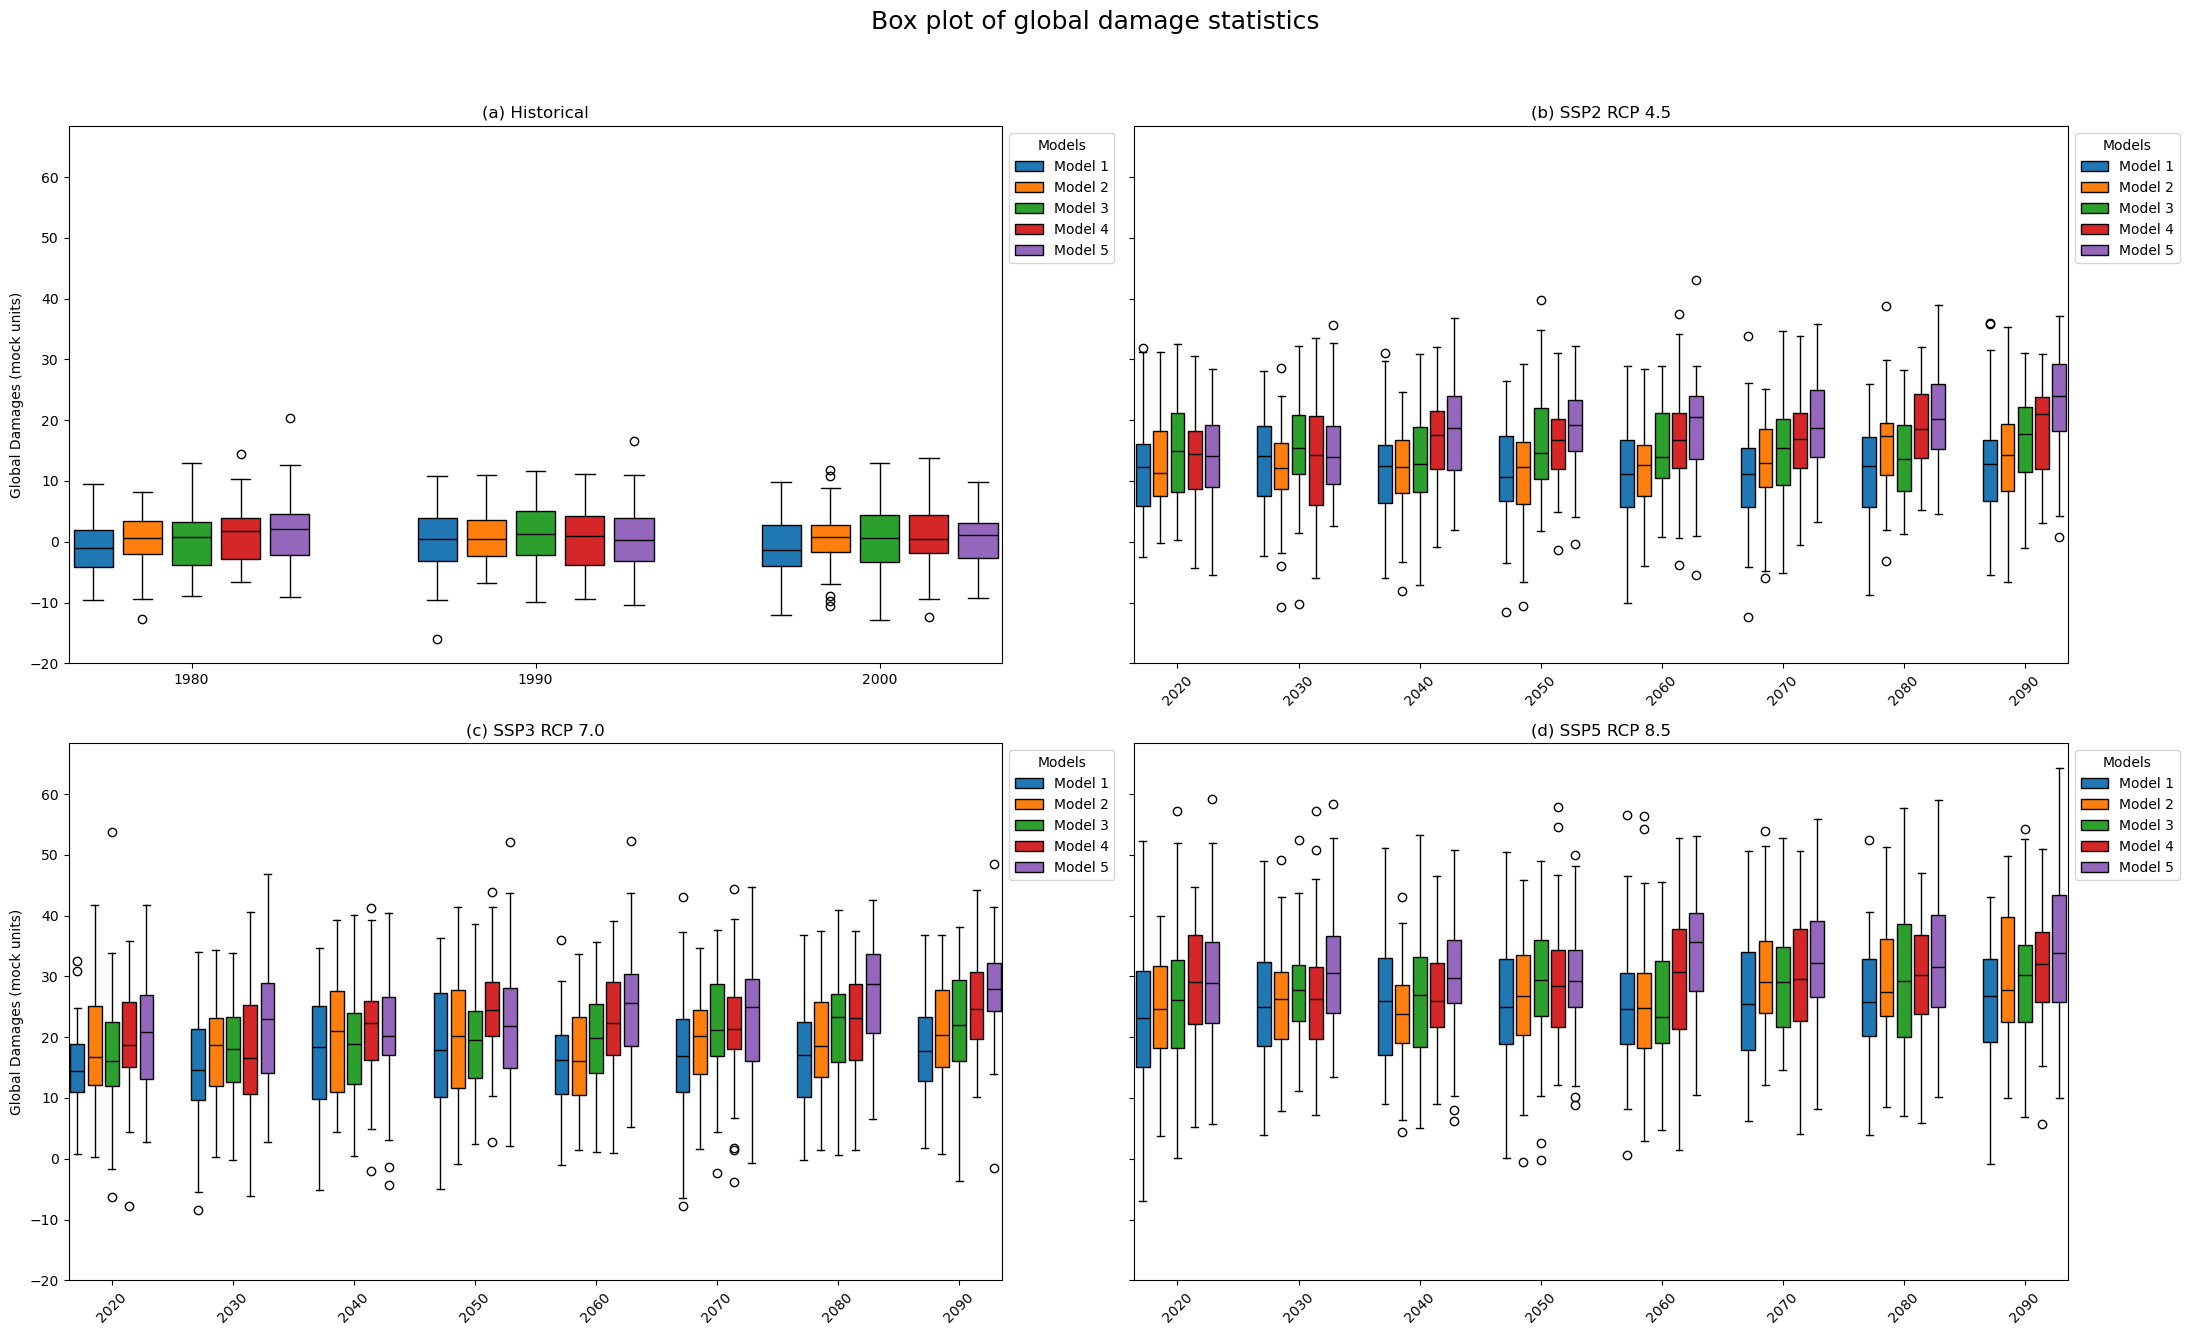

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def generate_mock_data(years, num_models=5, mean_func=None, scale=5):
    """
    Generate mock boxplot data for given years and number of models.
    mean_func: function(year, model_index) -> mean value for this model/year
    Returns: dict of years -> list of arrays (one per model)
    """
    data = {}
    for year in years:
        yearly_data = []
        for mi in range(num_models):
            mean = mean_func(year, mi) if mean_func else (mi + 1) * year / 10000
            yearly_data.append(np.random.normal(loc=mean, scale=scale, size=50))
        data[year] = yearly_data
    return data

def plot_grouped_boxplots(ax, data, years, models, title, xtick_rotation=0, ylabel=None, model_colors=None):
    """
    Plot grouped boxplots for multiple years, each with values per model.
    Each model gets its own color.
    """
    if model_colors is None:
        # Use builtin tab10 repeated if not enough models
        cmap = plt.cm.get_cmap('tab10')
        model_colors = [cmap(i % 10) for i in range(len(models))]
    positions = []
    boxplots_data = []
    box_colors = []
    base = 0
    gap = 2.0
    num_models = len(models)
    for y in years:
        for m in range(num_models):
            positions.append(base + m)
            boxplots_data.append(data[y][m])
            box_colors.append(model_colors[m])
        base += num_models + gap
    # Calculate year label positions for center of each group
    step = num_models + gap
    xtick_positions = [i*step + (num_models-1)/2 for i in range(len(years))]
    bp = ax.boxplot(boxplots_data, positions=positions, widths=0.8, patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    # Also color median lines etc. for better visualization if preferred
    for median, color in zip(bp['medians'], box_colors):
        median.set_color('black')
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels([str(y) for y in years], rotation=xtick_rotation)
    ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    # Add legend for model colors
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=model_colors[i], edgecolor='black', label=models[i]) for i in range(num_models)]
    ax.legend(handles=handles, title="Models", loc="upper left", bbox_to_anchor=(1, 1))

# Settings
np.random.seed(42)
models = [f"Model {i+1}" for i in range(5)]
historical_years = [1980, 1990, 2000]
future_years = list(range(2020, 2100, 10))
num_models = 5

# Assign distinct colors for models (repeat tab10 if more than 10)
cmap = plt.cm.get_cmap('tab10')
model_colors = [cmap(i % 10) for i in range(num_models)]

# Mean functions for variety in plots
def mean_historical(year, mi):
    return (mi + 1) * year / 9000

def mean_future(year, mi):
    return (mi + 1) * (year - 1980) / 50 + 10

# Data generation
historical_data = generate_mock_data(historical_years, num_models, mean_historical, scale=5)
future_scenarios = {
    "SSP2 RCP 4.5": generate_mock_data(future_years, num_models, mean_future, scale=8),
    "SSP3 RCP 7.0": generate_mock_data(future_years, num_models, lambda y, mi: mean_future(y, mi) + 6, scale=9),
    "SSP5 RCP 8.5": generate_mock_data(future_years, num_models, lambda y, mi: mean_future(y, mi) + 14, scale=10)
}

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(22, 14), sharey=True)
axes = axes.flatten()

plot_grouped_boxplots(
    axes[0], historical_data, historical_years, models,
    title="(a) Historical", ylabel="Global Damages (mock units)", model_colors=model_colors
)
plot_grouped_boxplots(
    axes[1], future_scenarios["SSP2 RCP 4.5"], future_years, models,
    title="(b) SSP2 RCP 4.5", xtick_rotation=45, model_colors=model_colors
)
plot_grouped_boxplots(
    axes[2], future_scenarios["SSP3 RCP 7.0"], future_years, models,
    title="(c) SSP3 RCP 7.0", xtick_rotation=45, ylabel="Global Damages (mock units)", model_colors=model_colors
)
plot_grouped_boxplots(
    axes[3], future_scenarios["SSP5 RCP 8.5"], future_years, models,
    title="(d) SSP5 RCP 8.5", xtick_rotation=45, model_colors=model_colors
)

plt.suptitle("Box plot of global damage statistics", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Figure 16